# Visión por computadora

## TP 2 

Tomás Abraham

A2602

In [1]:
import numpy as np
import cv2

In [2]:
video = cv2.VideoCapture('focus_video.mov')

In [3]:
# Dimensiones del video
frame_width = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Obtén la tasa de cuadros (frame rate) del video
fps = int(video.get(cv2.CAP_PROP_FPS))
#fps = 35
delay = int(600 / fps)

print("Las dimensiones del video son: ")
print("- Ancho: ", frame_width , " px")
print("- Alto: ", frame_height , " px")

print("Y los FPS son: ", fps)

Las dimensiones del video son: 
- Ancho:  640  px
- Alto:  360  px
Y los FPS son:  29


In [4]:
video = cv2.VideoCapture('focus_video.mov')

while True:
    ret, frame = video.read()
    if not ret:
        break
    
    # Mostrar el frame combinado
    cv2.imshow('Video TP2', frame)
    
    # Salir del loop si se presiona la tecla 'q'
    if cv2.waitKey(delay) & 0xFF == ord('q'):
        break
        
# Libera el objeto de captura de video y cierra todas las ventanas
video.release()
cv2.destroyAllWindows()

Voy a crear la función para detectar el enfoque en un frame que explica el paper

![](IMS.png)


In [5]:
def obtainIQM(img):

    # Paso 0 : dimensiones de la imagen
    M = img.shape[0]
    N = img.shape[1]

    # Paso 1 : calculo la FFT
    F = np.fft.fft2(img)

    # Paso 2 : desplazo el resultado de la FFT para que el origen quede en el centro
    Fc = np.fft.fftshift(F)

    # Paso 3 : calculo el módulo
    AFc = np.abs(Fc)

    # Paso 4 : máximo valor de componente de frecuencia de la imagen
    M = np.max(AFc)

    # Paso 5 : calcular Th (número de píxeles en AF cuyo valor es mayor a thresold = M/1000)
    thres = M/1000
    Th = np.sum(AFc>thres)

    # Paso 6 :  calculo el indicador de calidad de imagen
    IQM = Th / (M * N) 

    # devuelvo el indicador, y la imagen con la fft centrada y con módulo
    return IQM , AFc
    
    

Pruebo la función con un frame

In [6]:
video = cv2.VideoCapture('focus_video.mov')

# voy a tomar dos frames del video, uno del inicio y otro más adelante
for i in range(145):

    # recorro el video
    ret, frame = video.read()

    # si es el frame nº 2 
    if i == 2:
        FR_1 = frame
        IQM_1 , FFT_1  = obtainIQM(frame)

    # si es el frame nº 144
    if i == 85:
        FR_2 = frame
        IQM_2 , FFT_2  = obtainIQM(frame)
    


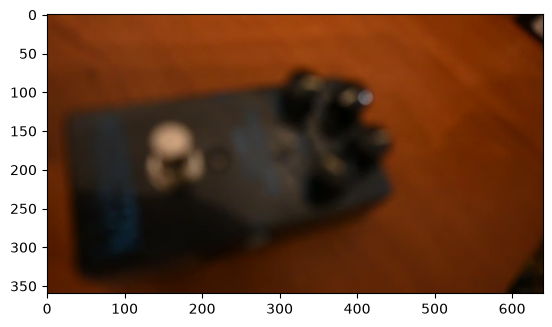

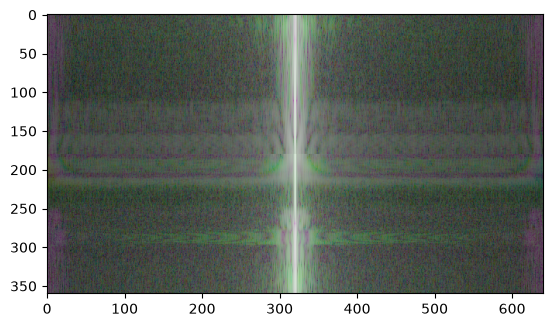

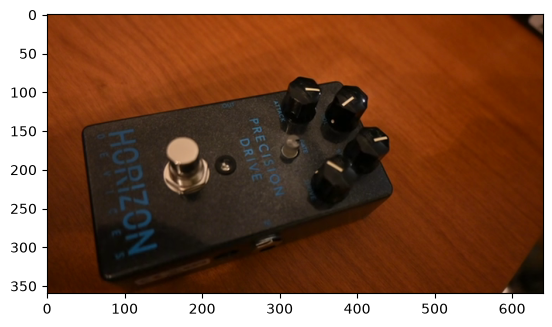

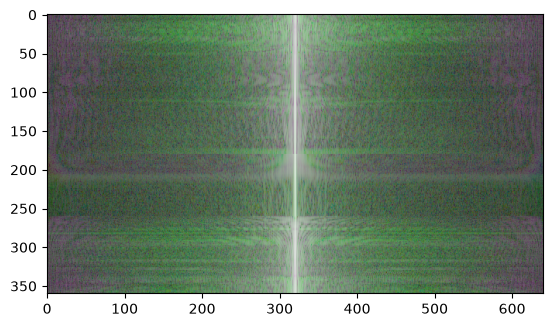

El primer IQM es:  0.0008848797250859107  y el segundo es:  0.0019835739068921375


In [7]:
import matplotlib.pyplot as plt

FFT_1_p = np.log1p(FFT_1)
FFT_1_p = cv2.normalize(FFT_1_p, None, 0, 255, cv2.NORM_MINMAX)
FFT_1_p = FFT_1_p.astype(np.uint8)

FFT_2_p = np.log1p(FFT_2)
FFT_2_p = cv2.normalize(FFT_2_p, None, 0, 255, cv2.NORM_MINMAX)
FFT_2_p = FFT_2_p.astype(np.uint8)

FR_1 = cv2.cvtColor(FR_1, cv2.COLOR_BGR2RGB)
FR_2 = cv2.cvtColor(FR_2, cv2.COLOR_BGR2RGB)

plt.figure("Primera imagen")
plt.imshow(FR_1)
plt.show()

plt.figure("Primera FFT")
plt.imshow(FFT_1_p)
plt.show()

plt.figure("Segunda imagen")
plt.imshow(FR_2)
plt.show()

plt.figure("Segunda FFT")
plt.imshow(FFT_2_p)
plt.show()

print("El primer IQM es: ", IQM_1, " y el segundo es: ", IQM_2)

En los resultados de las imagenes vistas se puede observar que la primera desenfocada y la segunda con un buen enfoque, y esto se ve reflejado en las intensidades de las FFT que se grafican luego de las imagenes. Vamos con el gráfico de indicadores de calidad de imagen:

Gráfico de ISM vs frame de todo el video:

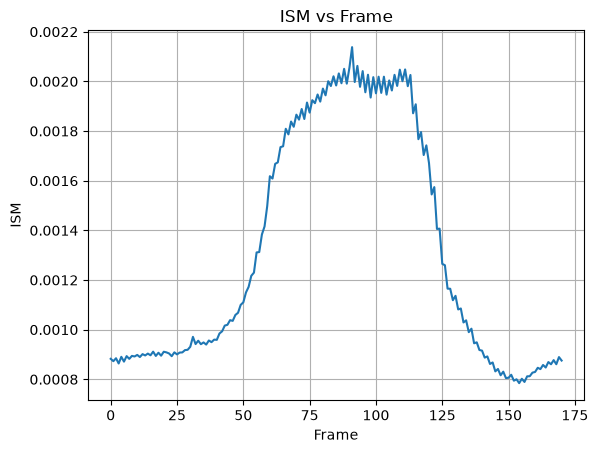

In [9]:
# vuelvo a leer el video
video = cv2.VideoCapture('focus_video.mov')

array_ISM = []

while 1:

    # recorro el video
    ret, frame = video.read()

    if not ret:
            break

    ISM , _ = obtainIQM(frame)

    array_ISM.append(ISM)

frames = np.arange(len(array_ISM))

plt.plot(frames, array_ISM)
plt.xlabel("Frame")
plt.ylabel("ISM")
plt.title("ISM vs Frame")
plt.grid()
plt.show()

Gráfico de ISM vs frame de un ROI del video:
Sabiendo que los frames tienen 640 x 360

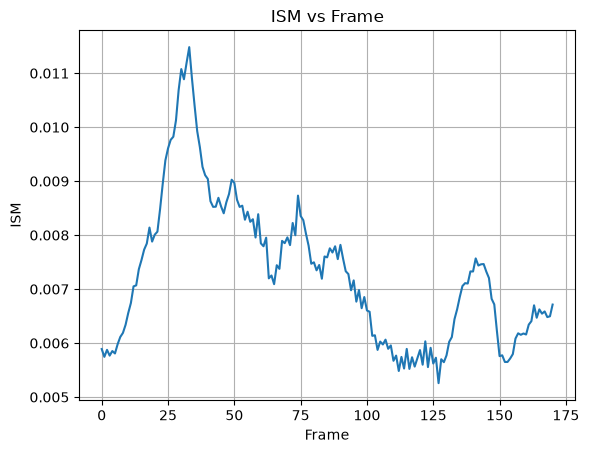

In [16]:
# vuelvo a leer el video
video = cv2.VideoCapture('focus_video.mov')

array_ISM_ROI = []

while 1:

    # recorro el video
    ret, frame = video.read()

    if not ret:
            break

    ISM , _ = obtainIQM(frame[120:160, 100:160])

    array_ISM_ROI.append(ISM)

frames = np.arange(len(array_ISM_ROI))

plt.plot(frames, array_ISM_ROI)
plt.xlabel("Frame")
plt.ylabel("ISM")
plt.title("ISM vs Frame")
plt.grid()
plt.show()

Me falta detectar las regiones de máximo enfoque de las imagenes, así que voy a hacer eso ahora:

In [29]:
# Esta función parte la imagen en bloques de cierto tamaño y devuelve una matriz con el valor de ISM de cada bloque
def obtenerMapaDeEnfoque(img, tamanioBloque = 10):

    # dimensiones de la iamgen
    H, W = img.shape[:2]

    # mapa vacío
    mapa = []

    # recorro de arriba a abajo
    for j in range(0, H - tamanioBloque + 1, tamanioBloque):

        fila = []

        # recorro de izquierda a derecha
        for i in range(0, W - tamanioBloque + 1 , tamanioBloque):
            # defino el roi a analizar
            ROI = img[j:j+tamanioBloque, i:i+tamanioBloque]

            # calculo ISM del ROI
            ISM , _ = obtainIQM(ROI)

            # agrego el valor a la fila
            fila.append(ISM)

        # agrego la fila al mapa
        mapa.append(fila)

    # retorno el mapa
    return np.array(mapa)
    

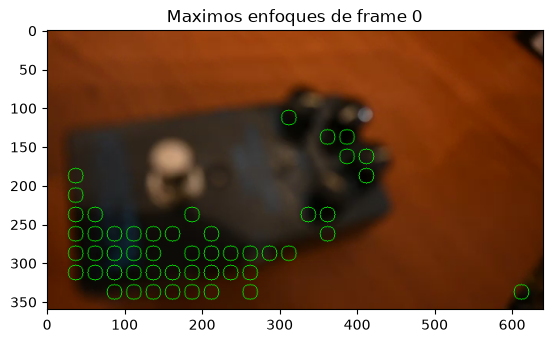

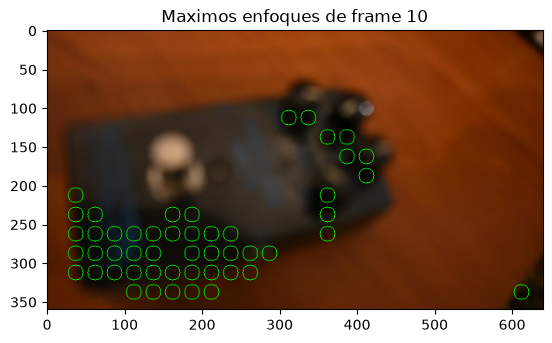

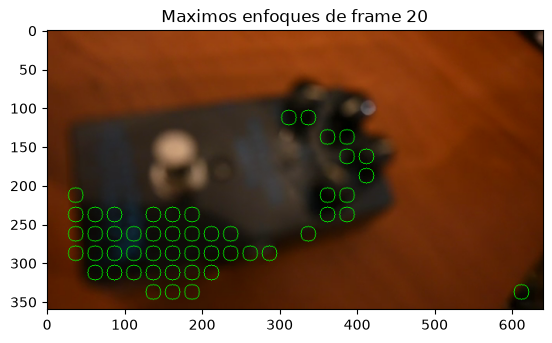

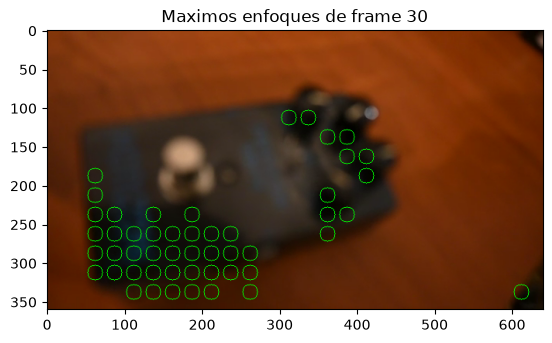

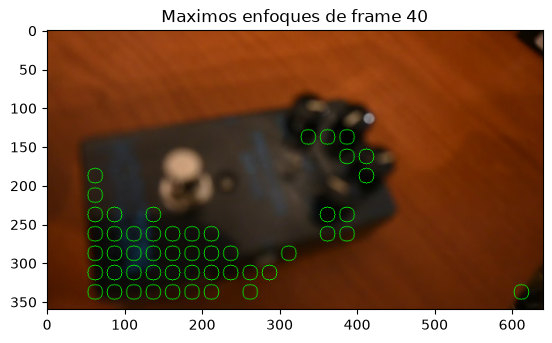

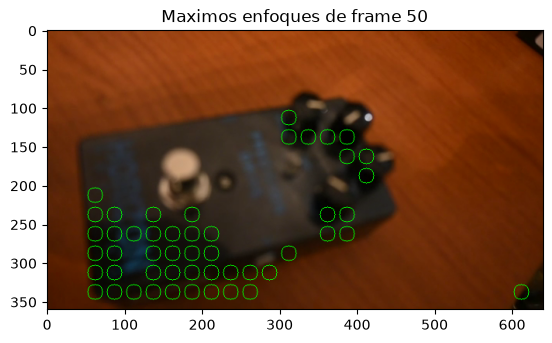

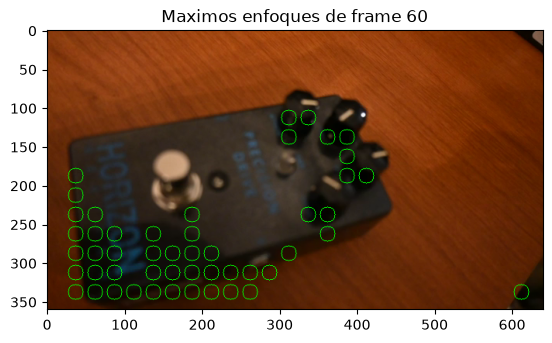

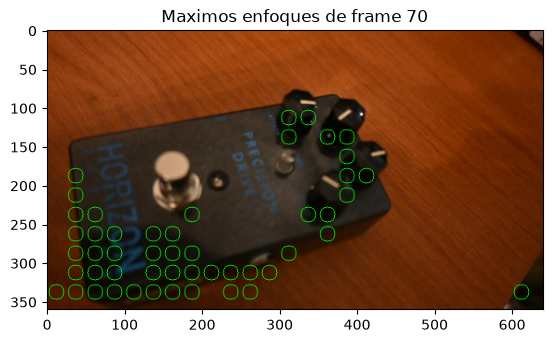

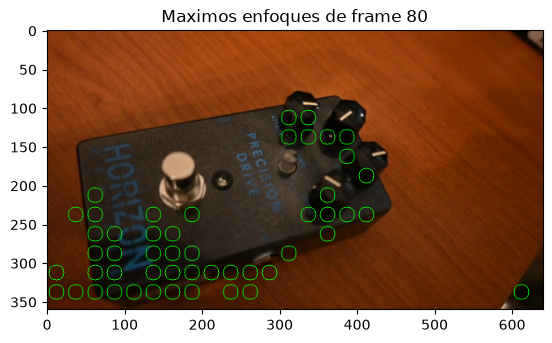

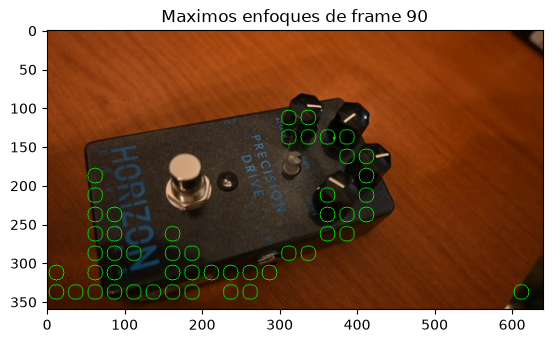

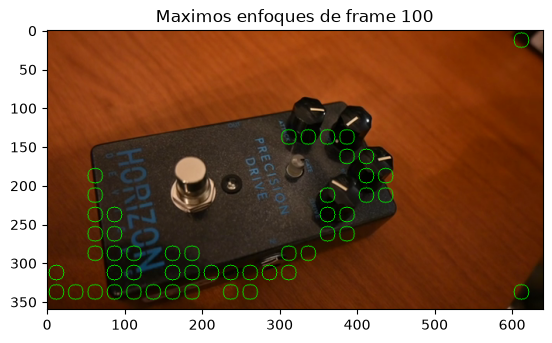

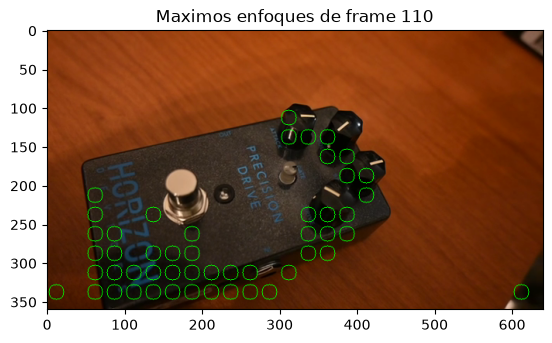

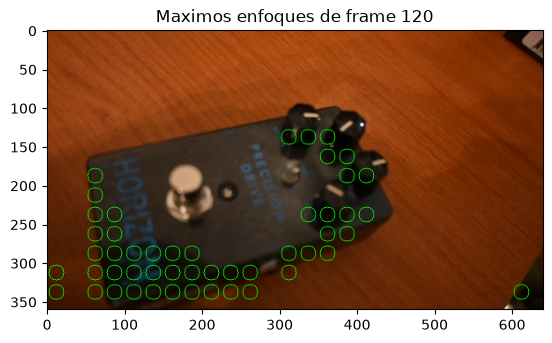

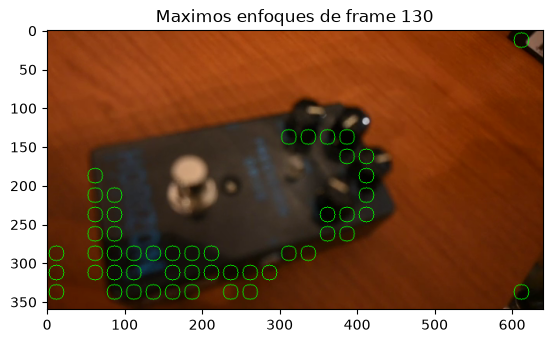

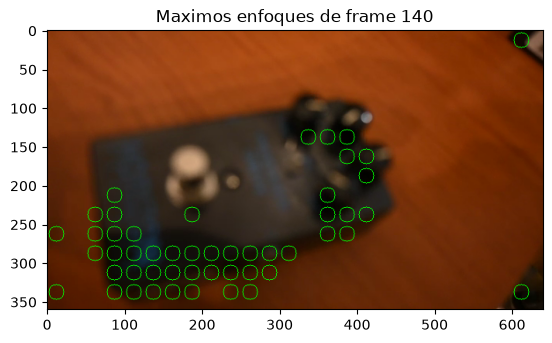

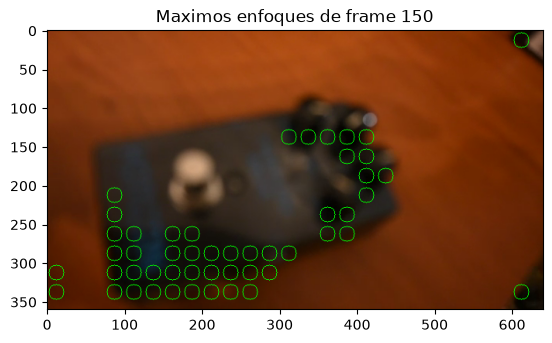

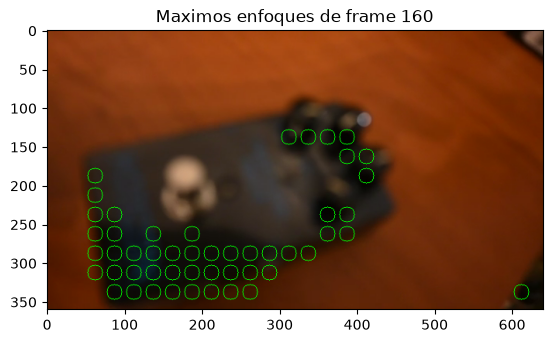

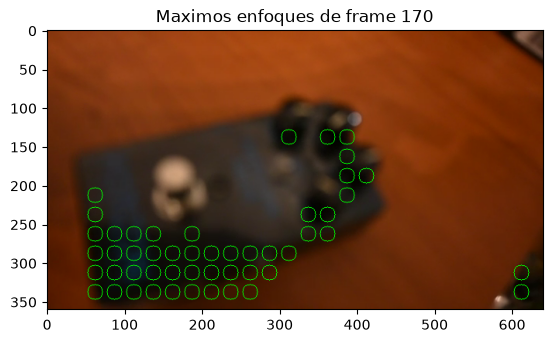

In [36]:
# vuelvo a leer el video
video = cv2.VideoCapture('focus_video.mov')

# defino el tamaño de los bloques en los que voy a partir la imagen
tamBloq = 25

# iterador
i = 0 

# entro en un loop para ver el video completo
while 1 :

    # recorro el video
    ret, frame = video.read()

    # si termina el video finalizo el loop
    if not ret:
            break

    # Si el numero de frame es multiplo de 10 (para no hacerlo con todos los frames)
    if i % 10 == 0:

        # calculo el mapa de enfoque
        mapa = obtenerMapaDeEnfoque(frame, tamBloq)

        # convierto el mapa a vector, me quedo con los 50 más grandes
        indices = np.argsort(mapa.ravel())[-50:][::-1]

        # inicializo el arreglo en donde voy a guardar los puntos de maximo enfoque
        puntos = []

        # recorro la lista de indices
        for indice in indices:

            # obtengo la fila y columna del indice
            fila, columna = np.unravel_index(indice, mapa.shape)

            # multiplico por el tamaño del bloque
            x = columna * tamBloq + tamBloq// 2
            y = fila * tamBloq + tamBloq// 2

            # agrego el punto
            puntos.append((x,y, mapa[fila,columna]))

        # copio la imagen
        resultado = frame.copy()
        # invierto canales BGR por RGB porque voy a graficar con matplotlib 
        resultado = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # recorro los puntos para agregar circulos en las regiones detectadas
        for x, y, ism in puntos:

            cv2.circle(
                resultado,
                (x,y),
                10,
                (0,255,0),
                1
            )

        plt.figure()
        plt.title(f"Maximos enfoques de frame {i}")
        plt.imshow(resultado)
        plt.show()
    
    i = i + 1 

    
    

Se puede observar en las imagenes que las zonas en donde mejores enfoques detecta es donde hay un borde o un cambio de textura, lo cual considero que es correcto ya que un borde bien definido se traduce en una frecuencia alta en el dominio espectral, lo cual se traduce en un máximo en la fft.

Si quisiera implementar ambos algoritmos en una misma función, puedo integrarlos:

In [37]:
def IQM_Regiones(img, blockSize):

    IQM, _ = obtainIQM(img)
    focusMap = obtenerMapaDeEnfoque(img, blockSize)

    return IQM, focusMap
    

Vamos a mostrar el video entero con las regiones de máximo enfoque, y al final muestro el grafico del enfoque en funcion del frame

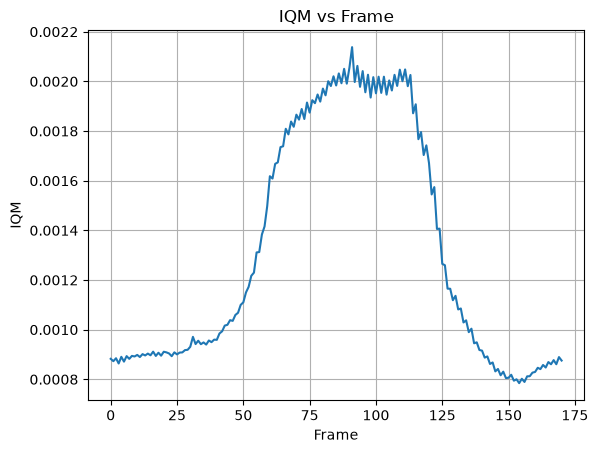

In [43]:
# vuelvo a leer el video
video = cv2.VideoCapture('focus_video.mov')

tamBloq = 30

array_IQM = []

while 1 :
    
    # recorro el video
    ret, frame = video.read()

    # si termina el video finalizo el loop
    if not ret:
            break


    # calculo el mapa de enfoque
    IQM, mapa = IQM_Regiones(frame, tamBloq)

    # convierto el mapa a vector, me quedo con los 50 más grandes
    indices = np.argsort(mapa.ravel())[-50:][::-1]

    # inicializo el arreglo en donde voy a guardar los puntos de maximo enfoque
    puntos = []

    # recorro la lista de indices
    for indice in indices:

        # obtengo la fila y columna del indice
        fila, columna = np.unravel_index(indice, mapa.shape)

        # multiplico por el tamaño del bloque
        x = columna * tamBloq + tamBloq// 2
        y = fila * tamBloq + tamBloq// 2

        # agrego el punto
        puntos.append((x,y, mapa[fila,columna]))

    # copio la imagen
    frame_procesado = frame.copy()

    # recorro los puntos para agregar circulos en las regiones detectadas
    for x, y, ism in puntos:

        cv2.circle(
            frame_procesado,
            (x,y),
            10,
            (0,255,0),
            1
        )
    
    # Mostrar el frame combinado
    cv2.imshow('Video procesado', frame_procesado)

    array_IQM.append(IQM)

    
    # Salir del loop si se presiona la tecla 'q'
    if cv2.waitKey(delay) & 0xFF == ord('q'):
        break
        
# Libera el objeto de captura de video y cierra todas las ventanas
video.release()
cv2.destroyAllWindows()


frames = np.arange(len(array_IQM))

plt.plot(frames, array_IQM)
plt.xlabel("Frame")
plt.ylabel("IQM")
plt.title("IQM vs Frame")
plt.grid()
plt.show()

    